In [15]:
!pip install matplotlib scikit-learn pandas numpy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 13.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.5 MB 21.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 20.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 34.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 39.7 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -----

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [17]:
model = LinearRegression()

In [23]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 27.70,
    "longitude": 85.32,
    "start_date": "2026-06-24",
    "end_date": "2026-07-23",
    "daily": "temperature_2m_mean",
    "timezone": "Asia/Kathmandu"
}

response = requests.get(url, params=params)
weather_data = response.json()

dates = weather_data['daily']['time']
temps = weather_data['daily']['temperature_2m_mean']

print(list(zip(dates, temps))[:5])  # sanity check the first 5 days

[('2026-06-24', 23.1), ('2026-06-25', 23.7), ('2026-06-26', 23.8), ('2026-06-27', 24.0), ('2026-06-28', 23.6)]


In [24]:
df = pd.DataFrame({'date': dates, 'temperature': temps})
print(df.shape)
df.head(10)

(30, 2)


,date,temperature
0,2026-06-24,23.1
1,2026-06-25,23.7
2,2026-06-26,23.8
3,2026-06-27,24.0
4,2026-06-28,23.6
5,2026-06-29,23.4
6,2026-06-30,22.9
7,2026-07-01,23.4
8,2026-07-02,23.3
9,2026-07-03,24.1


In [25]:
df = df.iloc[-20:].reset_index(drop=True)  # keep the last 20 rows (most recent dates)
df['cups'] = [3,3,3,3,2,2,2,2,2,1,2,1,1,1,1,1,1,3,2,2]
print(df.shape)
df

(20, 3)


,date,temperature,cups
0,2026-07-04,24.4,3
1,2026-07-05,24.4,3
2,2026-07-06,24.2,3
3,2026-07-07,23.7,3
4,2026-07-08,23.3,2
5,2026-07-09,23.5,2
6,2026-07-10,23.6,2
7,2026-07-11,23.3,2
8,2026-07-12,23.3,2
9,2026-07-13,22.7,1


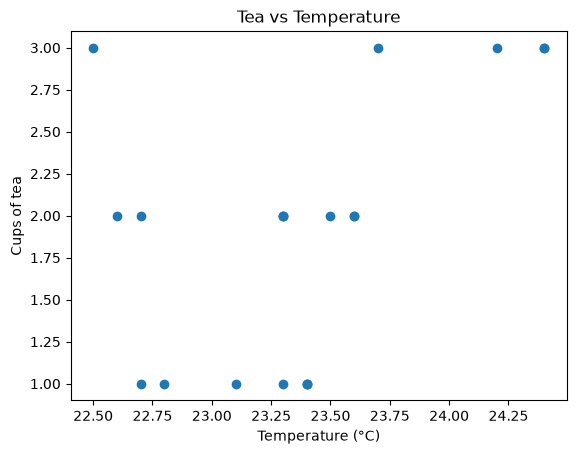

In [28]:
plt.scatter(df['temperature'], df['cups'])
plt.xlabel('Temperature (°C)')
plt.ylabel('Cups of tea')
plt.title('Tea vs Temperature')
plt.show()

In [29]:
X = df[['temperature']]  # double brackets = keeps it 2D, sklearn needs that
y = df['cups']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.760841998478317
Intercept: -15.991884352016257


In [31]:
y_pred = model.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: -0.33312922434059344
MAE: 0.7707329444585351


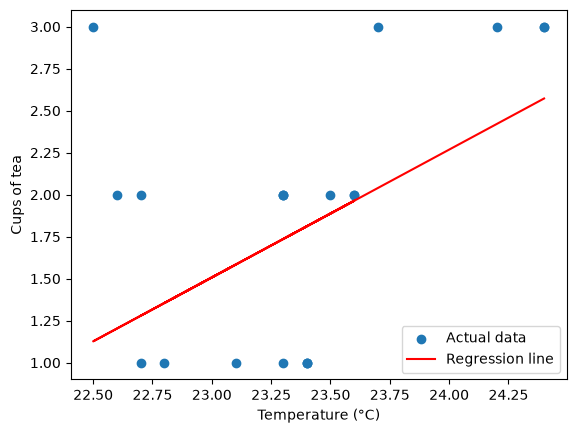

In [32]:
plt.scatter(X, y, label='Actual data')
plt.plot(X, model.predict(X), color='red', label='Regression line')
plt.xlabel('Temperature (°C)')
plt.ylabel('Cups of tea')
plt.legend()
plt.show()

In [43]:
model.predict([[24]])  # e.g. 

D:\Career\Python\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.26832361])